In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
train_path = "../data/raw/train.csv"
test_path = "../data/raw/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

train shape: (100000, 28)
test shape: (50000, 27)


/var/folders/gw/6hw2mnqn2p3c3ylx1sjb3gsw0000gn/T/ipykernel_47349/984007168.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_path)


In [6]:
train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


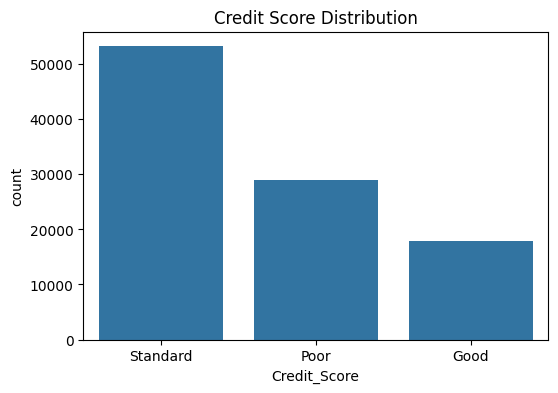

In [9]:
target = "Credit_Score"

target_count = train_df[target].value_counts()
target_ratio = train_df[target].value_counts(normalize=True) * 100

pd.DataFrame({
    "count": target_count,
    "ratio": target_ratio
})

plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x=target, order=target_count.index)

plt.title("Credit Score Distribution")

plt.show()

In [10]:
missing_df = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_ratio": train_df.isnull().mean() * 100
})

missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
    by="missing_count",
    ascending=False
)

missing_df

,missing_count,missing_ratio
Monthly_Inhand_Salary,15002,15.002
Type_of_Loan,11408,11.408
Name,9985,9.985
Credit_History_Age,9030,9.030
Num_of_Delayed_Payment,7002,7.002
Amount_invested_monthly,4479,4.479
Num_Credit_Inquiries,1965,1.965
Monthly_Balance,1200,1.200


In [11]:
dirty_values = ["_", "_______", "!@9#%8"]

dirty_summary = []

for value in dirty_values:
    for col in train_df.columns:
        count = (train_df[col] == value).sum()
        if count > 0:
            dirty_summary.append({
                "dirty_value": value,
                "column": col,
                "count": count,
                "ratio": count / len(train_df) * 100
            })

dirty_summary_df = pd.DataFrame(dirty_summary)
dirty_summary_df

,dirty_value,column,count,ratio
0,_,Changed_Credit_Limit,2091,2.091
1,_,Credit_Mix,20195,20.195
2,_______,Occupation,7062,7.062
3,!@9#%8,Payment_Behaviour,7600,7.600


In [12]:
numeric_like_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

for col in numeric_like_cols:
    print("=" * 60)
    print(col)
    print(train_df[col].head(10).tolist())

Age
['23', '23', '-500', '23', '23', '23', '23', '23', '28_', '28']
Annual_Income
['19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '34847.84', '34847.84']
Num_of_Loan
['4', '4', '4', '4', '4', '4', '4', '4', '1', '1']
Num_of_Delayed_Payment
['7', nan, '7', '4', nan, '4', '8_', '6', '4', '1']
Changed_Credit_Limit
['11.27', '11.27', '_', '6.27', '11.27', '9.27', '11.27', '11.27', '5.42', '7.42']
Outstanding_Debt
['809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '605.03', '605.03']
Amount_invested_monthly
['80.41529543900253', '118.28022162236736', '81.699521264648', '199.4580743910713', '41.420153086217326', '62.430172331195294', '178.3440674122349', '24.785216509052056', '104.291825168246', '40.39123782853101']
Monthly_Balance
['312.49408867943663', '284.62916249607184', '331.2098628537912', '223.45130972736786', '341.48923103222177', '340.4792117872438', '244.5653167062043', '358.12416760938714', '470.690626

In [13]:
eda_df = train_df.copy()

for col in numeric_like_cols:
    eda_df[col] = (
        eda_df[col]
        .astype(str)
        .str.replace("_", "", regex=False)
    )
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

eda_df[numeric_like_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01
Outstanding_Debt,100000.0,1.426220e+03,1.155129e+03,2.300000e-01,566.072500,1166.155000,1945.962500,4.998070e+03
Amount_invested_monthly,95521.0,6.374130e+02,2.043319e+03,0.000000e+00,74.534002,135.925682,265.731733,1.000000e+04
Monthly_Balance,98800.0,-3.036437e+22,3.181295e+24,-3.333333e+26,270.092209,336.719190,470.220186,1.602041e+03


In [14]:
outlier_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

eda_df[outlier_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Num_Credit_Inquiries,98035.0,2.775425e+01,1.931773e+02,0.000000e+00,3.000000,6.000000,9.000000,2.597000e+03


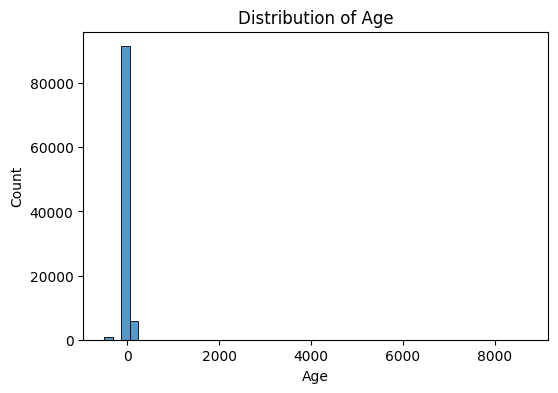

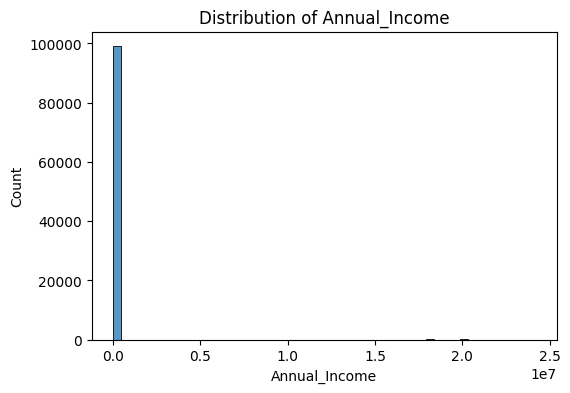

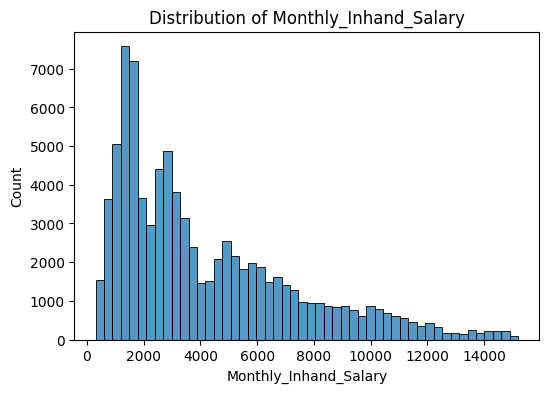

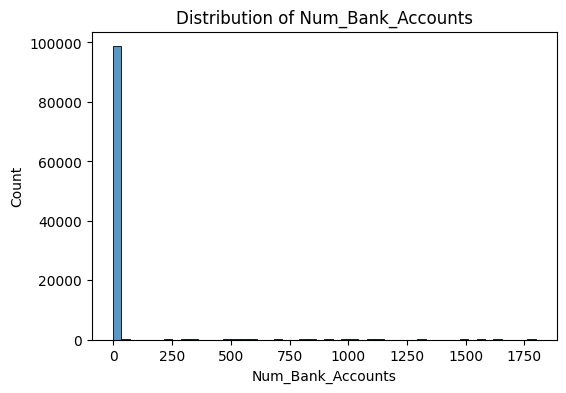

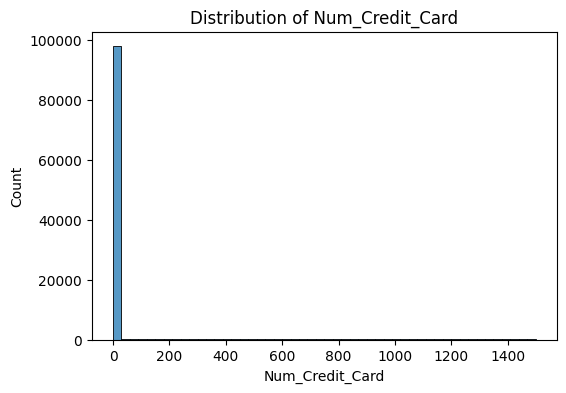

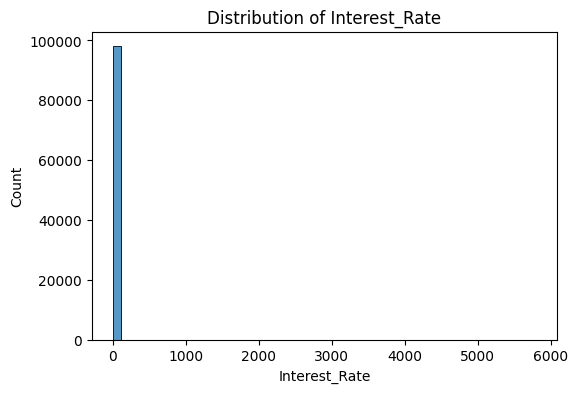

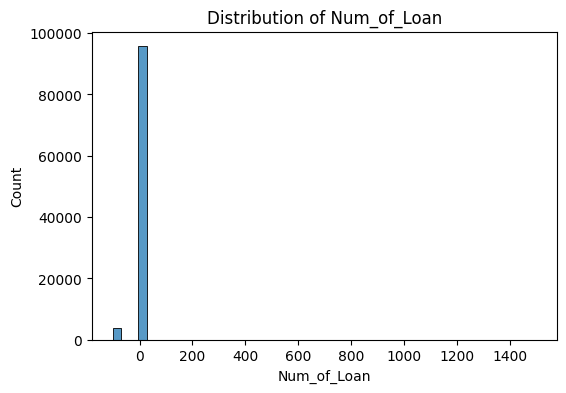

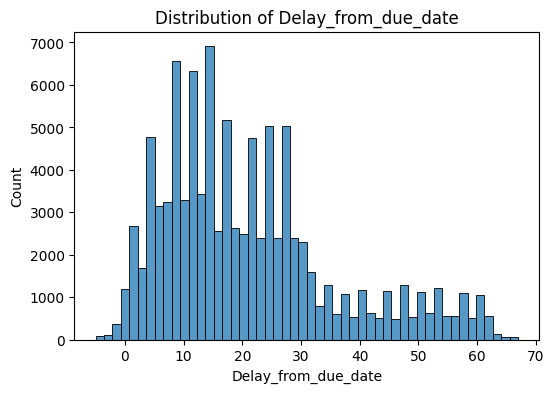

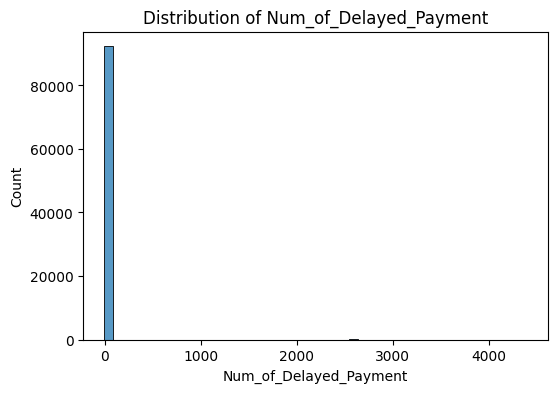

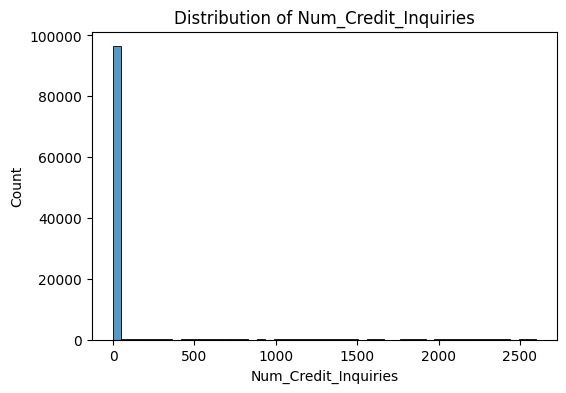

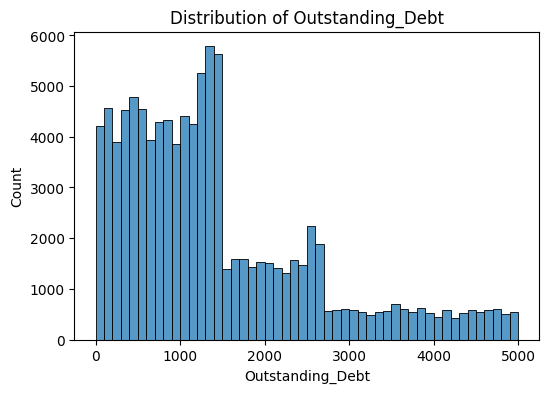

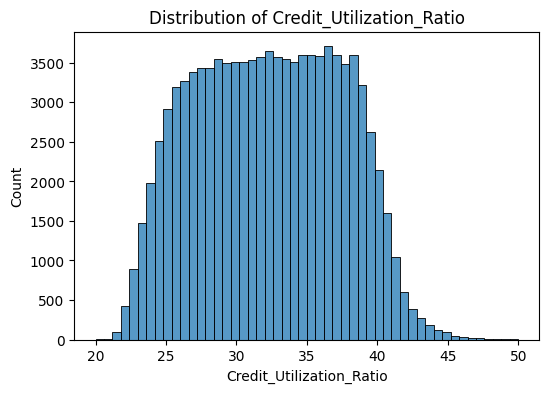

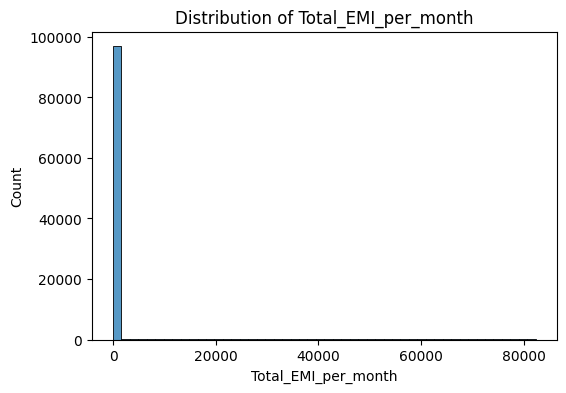

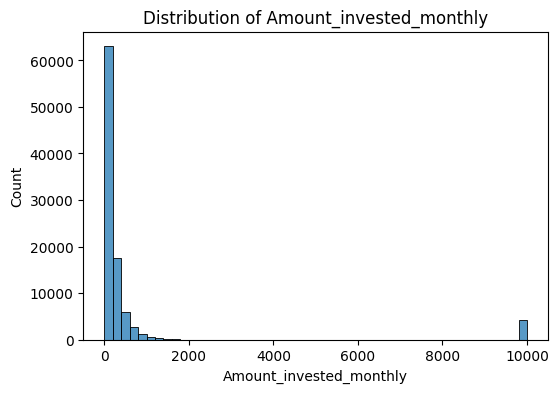

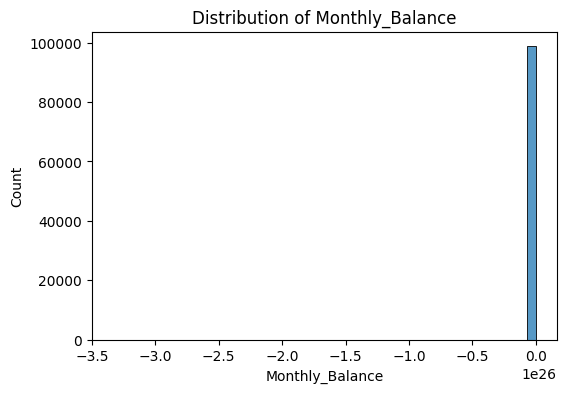

In [15]:
for col in outlier_cols:
    if col in eda_df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(eda_df[col].dropna(), bins=50)
        plt.title(f"Distribution of {col}")
        plt.show()

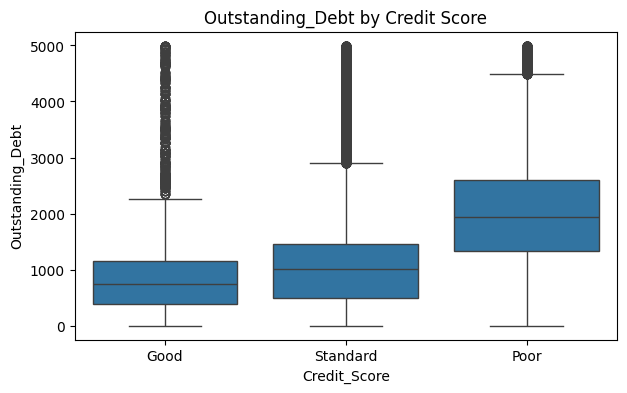

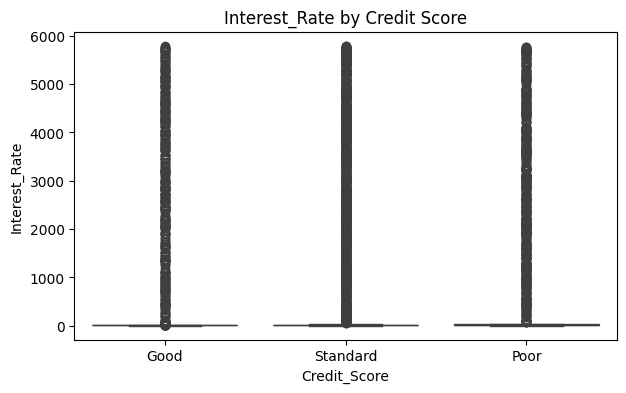

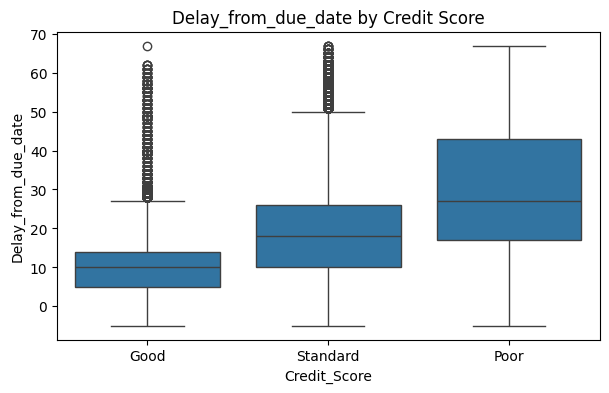

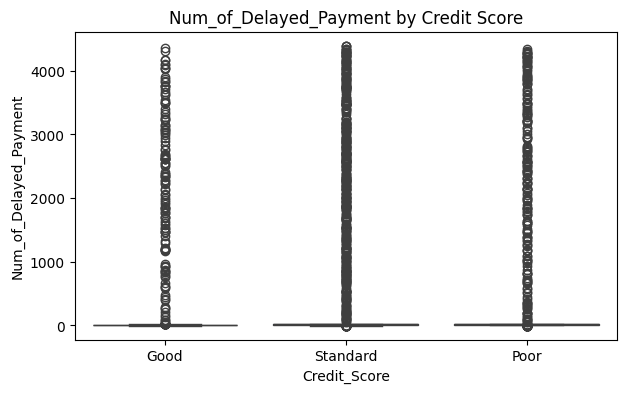

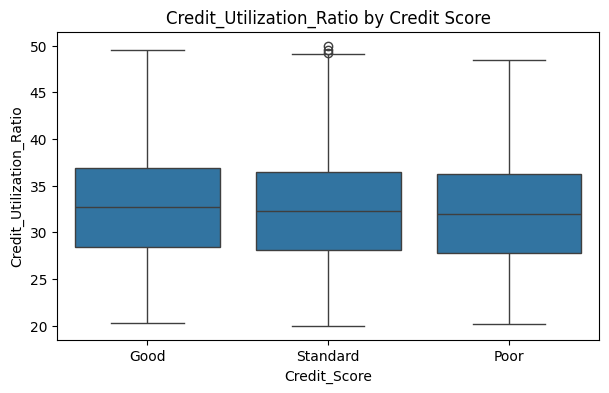

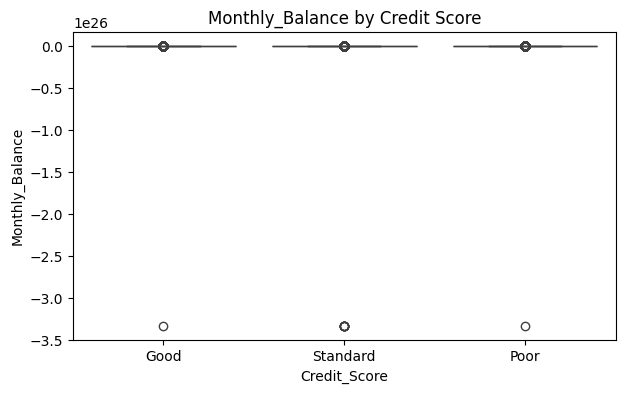

In [16]:
important_cols = [
    "Outstanding_Debt",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Credit_Utilization_Ratio",
    "Monthly_Balance",
]

for col in important_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=eda_df, x=target, y=col)
    plt.title(f"{col} by Credit Score")
    plt.show()

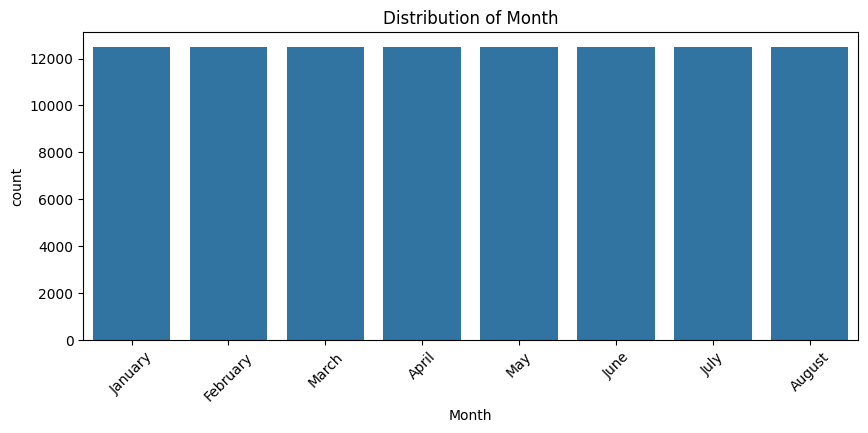

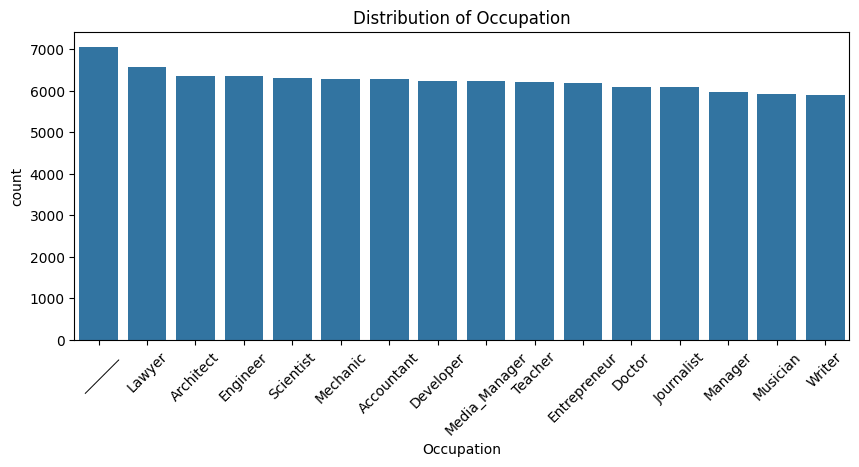

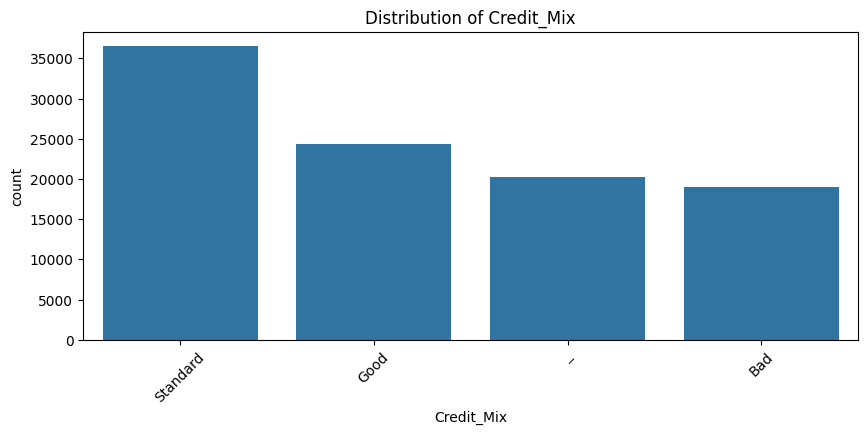

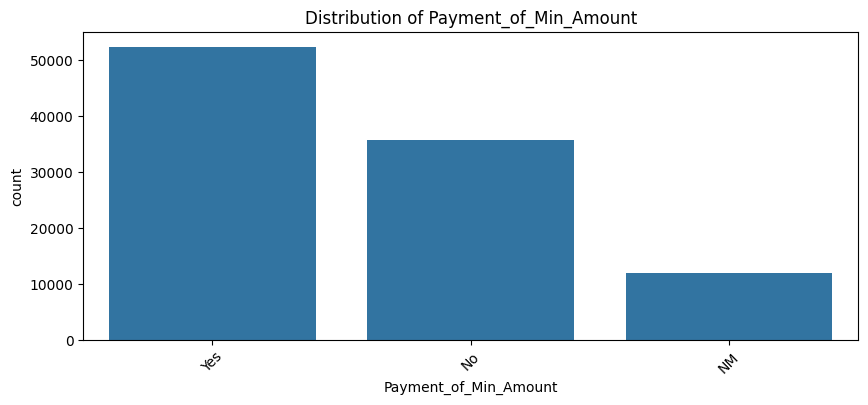

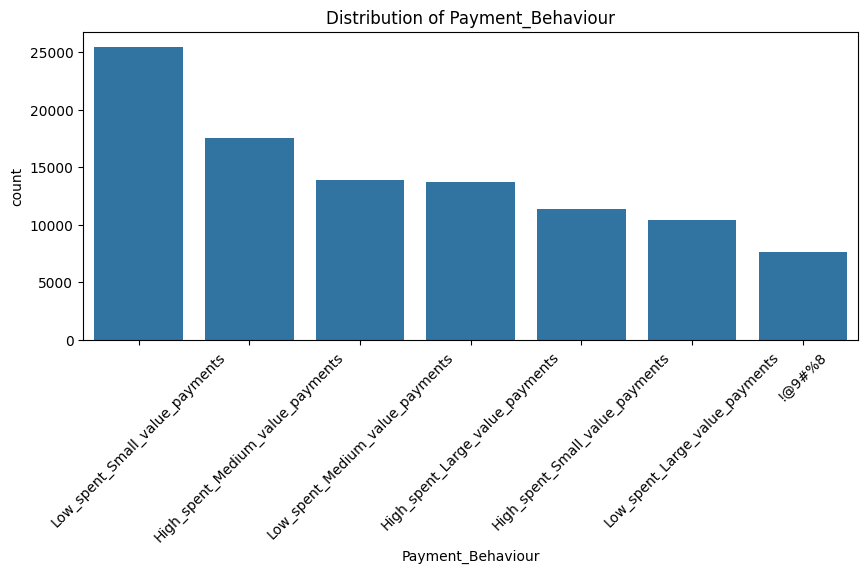

In [17]:
categorical_cols = [
    "Month",
    "Occupation",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=train_df,
        x=col,
        order=train_df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()